# Effects of Thermal Neutrino Cooling in Network Integrations


The previous notebook introduced the {py:meth}`sneut5 <pynucastro.neutrino_cooling.sneut5_mod.sneut5>` routine for evaluating thermal neutrino losses.  Here we show one way to use this loss term in a network integration.

We will compare two one-zone, self-heating integrations of the same He-burning network: one without thermal neutrino cooling and one with thermal neutrino cooling enabled.


When `self_heating=True`, adding `thermal_neutrinos=True` changes the temperature equation to

$$
\frac{dT}{dt} = \frac{\epsilon_\mathrm{nuc} - \epsilon_\nu}{c_V},
$$

where $\epsilon_\mathrm{nuc}$ is the nuclear energy generation rate, $\epsilon_\nu$ is evaluated with `sneut5`, and $c_V$ is the specific heat from the equation of state.


```{note}
This is a one-zone calculation.  It does not include hydrodynamic expansion or transport, so it is intended to demonstrate how the cooling term enters the network integration rather than to model a full stellar environment.
```


## Network Setup


In [1]:
import matplotlib.pyplot as plt
import pynucastro as pyna


We use a small He-burning network and initialize the zone with pure $^4\mathrm{He}$.


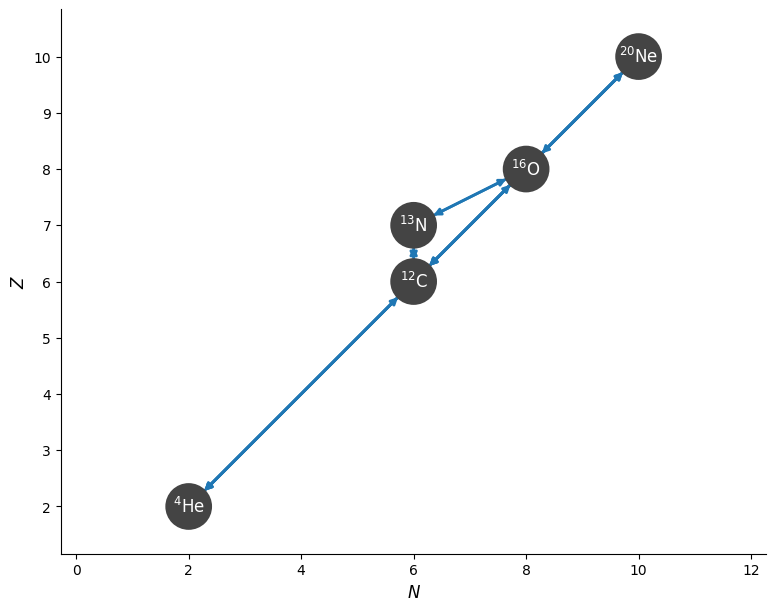

In [2]:
net = pyna.network_helper(["p", "he4", "c12", "n13", "o16", "ne20"])
fig = net.plot()


In [6]:
rho = 1.e5
T = 2.e8

comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("he4")] = 1
comp.normalize()
Y0 = comp.get_molar_array()

tmax = 1.e7


First we integrate with self-heating, but without thermal neutrino cooling.


In [7]:
sol_no_cooling = net.integrate_network(tmax, rho, T, Y0,
                                       self_heating=True,
                                       rtol=1.e-6, atol=1.e-6)


/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


Now we repeat the integration with `thermal_neutrinos=True`.  This evaluates `sneut5` along the trajectory and subtracts the neutrino loss rate from the nuclear energy generation rate in the temperature equation.


In [8]:
sol_cooling = net.integrate_network(tmax, rho, T, Y0,
                                    self_heating=True,
                                    thermal_neutrinos=True,
                                    rtol=1.e-6, atol=1.e-6)


/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


## Energy Generation and Neutrino Loss


For the cooled trajectory, we can compare the nuclear energy generation rate, $\epsilon_\mathrm{nuc}$, with the thermal neutrino loss rate, $\epsilon_\nu$.


/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/networks/python_network.py:615: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


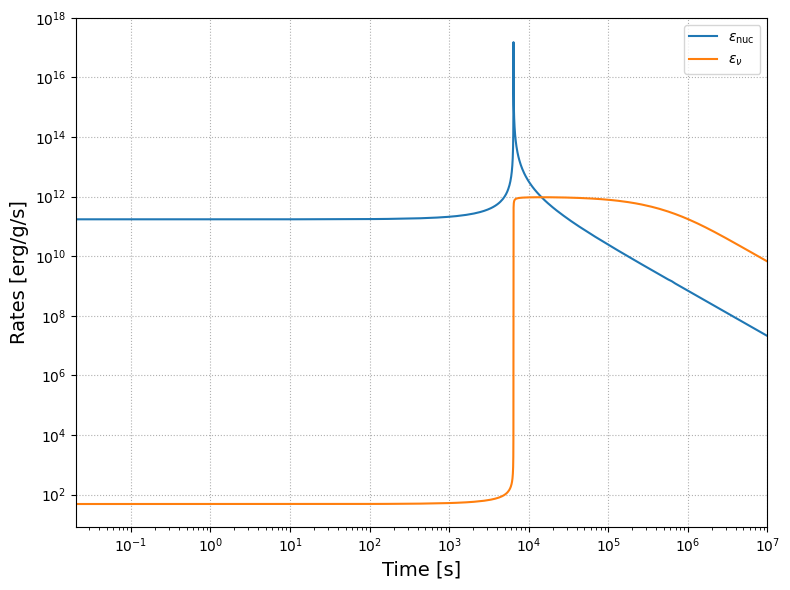

In [10]:
fig = sol_cooling.plot_energy_generation(ymax=1.e18,
                                         include_neutrino_loss=True)


During the runaway, $\epsilon_\mathrm{nuc}$ is much larger than $\epsilon_\nu$.  After the peak, the nuclear energy generation rate falls while the neutrino loss rate remains large for longer.


## Temperature Evolution


The effect of the loss term is visible by comparing the temperature histories from the two integrations.


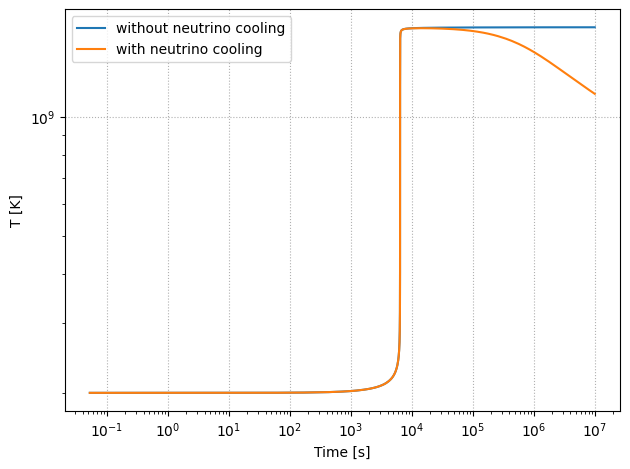

In [11]:
fig, ax = plt.subplots()

mask_no_cooling = sol_no_cooling.t > 0
mask_cooling = sol_cooling.t > 0

ax.loglog(sol_no_cooling.t[mask_no_cooling],
          sol_no_cooling.Temp[mask_no_cooling],
          label="without neutrino cooling")
ax.loglog(sol_cooling.t[mask_cooling],
          sol_cooling.Temp[mask_cooling],
          label="with neutrino cooling")

ax.set_xlabel("Time [s]")
ax.set_ylabel("T [K]")
ax.legend()
ax.grid(ls=":")
fig.tight_layout()


The integration with thermal neutrino cooling cools after the runaway, while the integration without this loss term remains hot.  The difference arises because the cooling term changes the temperature history, and the reaction rates depend on temperature.
